# HFTS-2 in-situ stress profile (B6S slant well)

First-pass mechanical earth model from the processed B6S wireline logs. Computes:

- **$S_v$**: vertical (overburden) stress, by integrating the measured bulk density (with an assumed average overburden above the logged top);
- **$P_p$**: pore pressure, from an assumed gradient;
- **$S_{h\min}$ / $S_{H\max}$**: horizontal stresses, from the poroelastic uniaxial-strain + tectonic-strain relation.

$$S_{h\min}=\frac{\nu}{1-\nu}\,(S_v-\alpha P_p)+\alpha P_p+\frac{E}{1-\nu^2}\,\varepsilon_h+\frac{\nu E}{1-\nu^2}\,\varepsilon_H$$

**Calibration knobs** are in the next cell. Defaults give the uniaxial lower bound ($\varepsilon_h=\varepsilon_H=0$, so $S_{H\max}=S_{h\min}$); tune `EPS_H` so $S_{h\min}$ matches the HFTS-2 DFIT closure pressures.

**Caveats:** dynamic moduli overestimate static ones (apply a dynamic→static correction for a calibrated model); $S_{H\max}$ is unconstrained without breakout data; the overburden above the log top (~11,320 ft) is assumed, not measured.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Calibration knobs

In [2]:
# --- edit these ---
RHO_OVERBURDEN = 2400.0   # kg/m^3  average overburden density above the log top
PP_GRAD_PSFT   = 0.60     # psi/ft  pore-pressure gradient (Delaware Basin is overpressured)
BIOT           = 0.8      # Biot coefficient
EPS_H          = 0.0      # min horizontal tectonic strain (calibrate to DFIT closure)
EPS_H_MAX      = 0.0      # max horizontal tectonic strain

# unit conversions
FT, G, PSI, MPA = 0.3048, 9.81, 6894.757, 1.0e6
# input: rock-props table exported by wireline_logs_brittleness.ipynb (B6S run)
DATA_ROOT = "../inputs/field_data/well_logs"   # packaged well-logs subset (paths relative to notebooks/)
CSV_IN  = f"{DATA_ROOT}/B6S/b6s_rock_props_brittleness.csv"
CSV_OUT = "../data/b6s_stress_profile.csv"   # packaged copy consumed by buildInputTables_hfts2.py 

## Load the B6S logs

In [3]:
df = pd.read_csv(CSV_IN).sort_values("TVD_ft").reset_index(drop=True)
tvd  = df["TVD_ft"].to_numpy()
rhob = df["RHOB_gcc"].to_numpy()
nu   = df["PR_dyn"].to_numpy()
E    = df["E_GPa"].to_numpy() * 1e9          # Pa
print(f"{len(df)} samples, TVD {tvd.min():.0f}-{tvd.max():.0f} ft")

8545 samples, TVD 11085-11888 ft


## Vertical stress $S_v$

Assumed overburden above the density-log top, then trapezoidal integration of the measured density.

In [4]:
m = ~np.isnan(rhob)
tv, rh = tvd[m], rhob[m] * 1000.0            # kg/m^3
Sv_int = np.empty_like(tv)
Sv_int[0] = RHO_OVERBURDEN * G * (tv[0] * FT)
for i in range(1, len(tv)):
    Sv_int[i] = Sv_int[i-1] + 0.5 * (rh[i] + rh[i-1]) * G * ((tv[i] - tv[i-1]) * FT)
Sv = np.interp(tvd, tv, Sv_int)

## Pore pressure and horizontal stresses

In [5]:
Pp   = PP_GRAD_PSFT * tvd * PSI
poro = nu / (1 - nu) * (Sv - BIOT * Pp) + BIOT * Pp
# Tectonic terms skipped when both strains are zero (avoids nan*0 where E is missing)
if EPS_H == 0.0 and EPS_H_MAX == 0.0:
    Shmin = poro.copy(); SHmax = poro.copy()
else:
    Shmin = poro + E / (1 - nu**2) * EPS_H     + nu * E / (1 - nu**2) * EPS_H_MAX
    SHmax = poro + E / (1 - nu**2) * EPS_H_MAX + nu * E / (1 - nu**2) * EPS_H

## Summary

In [6]:
ok = ~np.isnan(Shmin)
band = lambda a: f"{np.nanmin(a[ok])/MPA:.0f}-{np.nanmax(a[ok])/MPA:.0f}"
print(f"Assumptions: overburden {RHO_OVERBURDEN:.0f} kg/m3, Pp {PP_GRAD_PSFT} psi/ft, Biot {BIOT}, tectonic strain ({EPS_H}, {EPS_H_MAX})")
print(f"TVD   {tvd[ok].min():.0f}-{tvd[ok].max():.0f} ft")
print(f"Sv    = {band(Sv)} MPa  (grad ~{np.nanmedian(Sv[ok]/(tvd[ok]*PSI)):.2f} psi/ft)")
print(f"Pp    = {band(Pp)} MPa  ({PP_GRAD_PSFT} psi/ft assumed)")
print(f"Shmin = {band(Shmin)} MPa (grad ~{np.nanmedian(Shmin[ok]/(tvd[ok]*PSI)):.2f} psi/ft)")

Assumptions: overburden 2400 kg/m3, Pp 0.6 psi/ft, Biot 0.8, tectonic strain (0.0, 0.0)
TVD   11197-11871 ft
Sv    = 81-85 MPa  (grad ~1.04 psi/ft)
Pp    = 46-49 MPa  (0.6 psi/ft assumed)
Shmin = 43-67 MPa (grad ~0.69 psi/ft)


## Save the stress profile

In [7]:
out = pd.DataFrame({
    "TVD_ft": tvd, "RHOB_gcc": rhob, "PR_dyn": nu, "E_GPa": E/1e9,
    "Sv_MPa": Sv/MPA, "Pp_MPa": Pp/MPA, "Shmin_MPa": Shmin/MPA, "SHmax_MPa": SHmax/MPA,
    "Sv_psift": Sv/(tvd*PSI), "Shmin_psift": Shmin/(tvd*PSI),
})
out = out[out["PR_dyn"].notna()]
out.to_csv(CSV_OUT, index=False)
print(f"wrote {CSV_OUT} ({len(out)} rows)")
out.head()

wrote ../data/b6s_stress_profile.csv (7832 rows)


,TVD_ft,RHOB_gcc,PR_dyn,E_GPa,Sv_MPa,Pp_MPa,Shmin_MPa,SHmax_MPa,Sv_psift,Shmin_psift
493,11196.7379,NaN,0.3701,NaN,81.236372,46.319272,63.014096,63.014096,1.052301,0.816258
494,11196.9287,NaN,0.3502,NaN,81.236372,46.320062,60.866374,60.866374,1.052283,0.788423
495,11197.1194,NaN,0.3486,NaN,81.236372,46.320850,60.699666,60.699666,1.052265,0.786251
496,11197.3102,NaN,0.3476,NaN,81.236372,46.321640,60.596002,60.596002,1.052247,0.784895
497,11197.5009,NaN,0.3476,NaN,81.236372,46.322429,60.596297,60.596297,1.052229,0.784885


## Plot: stress and elastic profiles vs depth

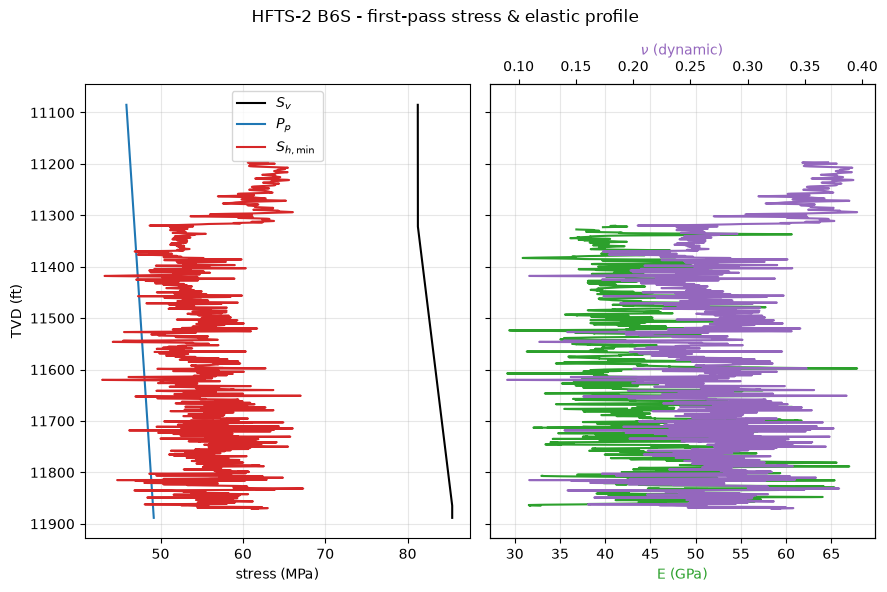

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 6), sharey=True)

ax[0].plot(Sv/MPA,    tvd, "k-",  label=r"$S_v$")
ax[0].plot(Pp/MPA,    tvd, "-",   color="tab:blue", label=r"$P_p$")
ax[0].plot(Shmin/MPA, tvd, "-",   color="tab:red",  label=r"$S_{h,\min}$")
ax[0].set_xlabel("stress (MPa)"); ax[0].set_ylabel("TVD (ft)")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(E/1e9, tvd, "-", color="tab:green", label="E")
ax[1].set_xlabel("E (GPa)", color="tab:green"); ax[1].grid(alpha=0.3)
axb = ax[1].twiny()
axb.plot(nu, tvd, "-", color="tab:purple")
axb.set_xlabel(r"$\nu$ (dynamic)", color="tab:purple")

ax[0].invert_yaxis()   # depth increases downward
fig.suptitle("HFTS-2 B6S - first-pass stress & elastic profile")
fig.tight_layout()
plt.show()